# Distribuições de probabilidade para variáveis contínuas

## Distribuição F de Snedecor

A distribuição F de Snedecor, também conhecida como distribuição de Fisher, é frequentemente utilizada em testes associados à análise de variância (ANOVA), para comparação de médias de mais de duas populações.

Consideremos as variáveis aleatórias contínuas $Y_1$ e $Y_2$, de modo que:

- $Y_1$ e $Y_2$ são independentes;
- $Y_1$ tem distribuição qui-quadrado com $\nu_1$ graus de liberdade
- $Y_2$ tem distribuição qui-quadrado com $\nu_2$ graus de liberdade

Definiremos uma nova variável aleatória contínua *X* tal que:

$$
X = \frac{ \frac{Y_1}{\nu_1} }{ \frac{Y_2}{\nu_2}}
$$

Dizemos que *X* tem uma distribuição *F* de Snedecor com $\nu_1$ e $\nu_2$ graus de liberdade se sua função densidade de probabilidade for dada por:

$$
f(x) = \frac{
    \Gamma \left( \frac{\nu_1 + \nu_2}{2} \right) \cdot 
    \left( \frac{\nu_1}{\nu_2} \right)^{\frac{\nu_1}{2}} 
    \cdot x^{\frac{\nu_1}{2}-1}
}{
    \Gamma \left( \frac{\nu_1}{2} \right) \cdot
    \Gamma \left( \frac{\nu_2}{2} \right) \cdot
    \left[ \left( \frac{\nu_1}{\nu_2} \right) \cdot x + 1 \right]^{\frac{\nu_1 + \nu_2}{2}}
} \qquad, x>0
$$

em que $\Gamma (\alpha) = \int\limits_{0}^{\infty} e^{-x} \cdot x^{\alpha - 1} dx $

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html

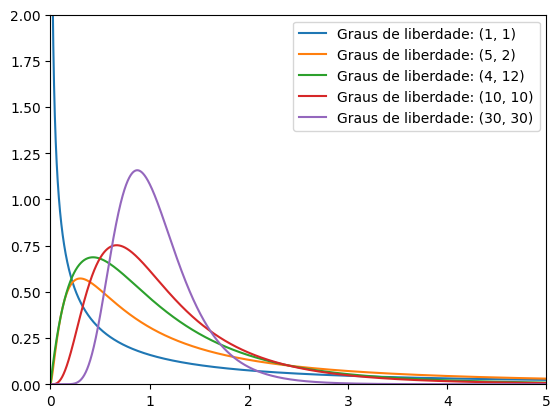

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import f

for graus_de_liberdade in ((1, 1), (5, 2), (4, 12), (10, 10), (30, 30)):
    x = np.linspace(0, 5, 10_000)
    y = f.pdf(x, *graus_de_liberdade)

    plt.plot(x, y, label=f"Graus de liberdade: {graus_de_liberdade}")

plt.xlim(0, 5)
plt.ylim(0, 2)
plt.legend()

plt.show()

Podemos notar que a distribuição F de Snedecor é assimétrica positiva (à direita), observando maior frequência para valores menores de *x* e uma cauda mais longa à direita. Porém, à medida que $\nu_1$ e $\nu_2$ tendem ao infinito, a distribuição torna-se simétrica.

Assim como as distribuições normal, $\chi^2$ e t de Student, a distribuição F de Snedecor apresenta diversas aplicações em inferência estatística.

In [2]:
graus_de_liberdade_exemplo = (10, 8)
alfa = 0.05

In [3]:
f.ppf(0.95, *graus_de_liberdade_exemplo)

np.float64(3.3471631202339784)

In [4]:
f.cdf(3.34716, *graus_de_liberdade_exemplo)

np.float64(0.9499998762192092)

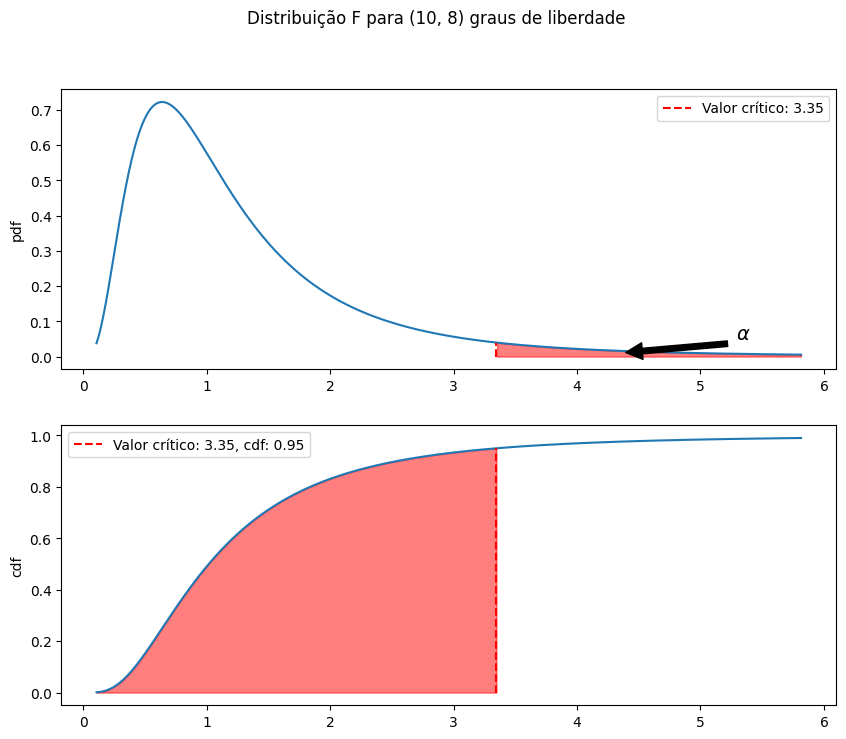

In [5]:
from graficos import plot_f_snedecor

plot_f_snedecor(graus_de_liberdade_exemplo, alfa)